In [2]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
import os

Welcome to JupyROOT 6.26/16


In [124]:
#lets see if we can incorporate the merged hit hit constituents into truth labels in any way that is practical?
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2543.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2543.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
const_hit_array = merged_hits_file['third']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002543.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [125]:
nns_in_file = np.unique(dbscan_hits[:,0])

In [5]:
#large loop here to create our truth dictionaries ~ file scale. 
#If I'm not mistaken this is the only real change that needs to be made to the existing infrastructure, since once dictionaries
#are created rest of ClusterToGraph should just cook.

In [6]:
%%time
dbscan_file_dict = {}
for nn in nns_in_file:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    const_hit_array_nn = const_hit_array[const_hit_array[:,0] == nn]

    np.unique(event_merged_hits[:,1]) #hit numbers
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    event_trajectories = event.Trajectories

    trackid_dict = {}
    pdgid_dict = {}
    #collapsed the pdgid dict into this one too. 
    #print(f'{nn} \n \n')
    exceptions_list = []
    for hit_num in np.unique(event_merged_hits[:,1]):
        const_hit_array_nn[const_hit_array_nn[:,1] == hit_num] #grab const hn
        const_hit_info = const_hit_array_nn[const_hit_array_nn[:,1] == hit_num] #grab const hit numbers
        #grab the default
        merged_hit_segment = event_hit_segments[int(hit_num)]
        default_trackid = (merged_hit_segment.Contrib)[0]
        default_traj = event_trajectories[default_trackid] 
        default_pdgid = default_traj.GetPDGCode()
        #now loop over the other possible constituent hits, in the case that not already a muon hit
        #print(hit_num)
        #print(hit_num)
        if abs(default_pdgid) != 13:
            for i, const_hit_num in enumerate(const_hit_info[:,-1]):
                #exception handling in the case of multi nn merge is going to be annoying, send to end!
                if const_hit_info[i][-2] != nn:
                    exceptions_list.append(np.array((hit_num, const_hit_num, const_hit_info[i][-2], default_trackid)))
                    #print("mulit neutrino weirdness, sending to exceptions stack")
                    #print(f"to check, nn {nn}: {(hit_num, const_hit_num, const_hit_info[i][-2], default_trackid)}")
                    #we add here the merged hit #, constituent hit #, the constituent nn, and the trackid at the instance. 
                    continue
                        
                #print(const_hit_num)
                hit_segment = event_hit_segments[int(const_hit_num)]
                contrib_vector = hit_segment.Contrib #grab associated trackid
                associated_traj = event_trajectories[contrib_vector[0]] 
                replaced = False
                if abs(associated_traj.GetPDGCode()) == 13 and replaced == False:
                    default_trackid = contrib_vector[0] #if a muon, prioritize
                    default_pdgid = associated_traj.GetPDGCode()
                    replaced = True
                    #print(f'Reassigned, now has trackid {default_trackid}')

        trackid_dict[int(hit_num)] = default_trackid
        pdgid_dict[default_trackid] = default_pdgid
        #print(f'confirming {default_trackid}')

    #handle the issues (mulit neutrino events)
    for exception in exceptions_list:
        #check if we need to handle in the first place
        if abs(pdgid_dict[int(exception[3])]) != 13:
            #set the events to 
            edep_events.GetEntry(int(exception[2]))
            event_hit_segments = event.SegmentDetectors['volTMS']
            event_trajectories = event.Trajectories
            trackid = ((event_hit_segments[int(exception[1])]).Contrib)[0] #grab the segment
            #update if needed. Feel this will be fairly rare. 
            if abs(event_trajectories[trackid].GetPDGCode()) == 13:
                trackid_dict[int(exception[0])] = trackid
                pdgid_dict[trackid] = event_trajectories[trackid].GetPDGCode()
                #print(f'Wow actually had to update something in exceptions! - {exception}')
        
        
    hit_info_dict = {}
    for hit_num in np.unique(event_merged_hits[:,1]):
        hit_trackid = trackid_dict[hit_num]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_num)] = (hit_trackid, hit_pdgid)

    dbscan_file_dict[int(nn)] = hit_info_dict   
        

CPU times: user 35.9 s, sys: 696 ms, total: 36.6 s
Wall time: 36.5 s


In [129]:
#ran on the big file. Got spammed w/ hull errors at the end, may want to patch to facilitate creation of <4 point 
torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/processed/file_2543_graphs.pt')

/lscratch/ktwall/tmp/ipykernel_550754/1105822409.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/processed

Text(0, 0.5, 'Hit X (mm)')

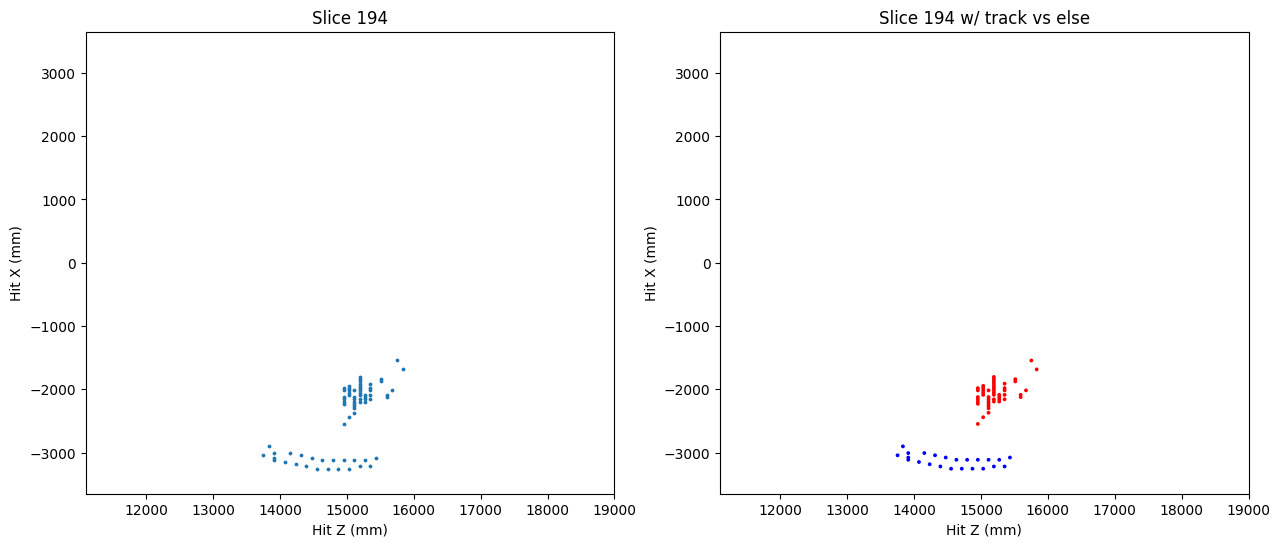

In [178]:
#selected cluster, can now take a look at the truth labels.
cluster_n = 194
zs = (torch_dataset[cluster_n].x)[:,0]
xs = (torch_dataset[cluster_n].x)[:,1]
nodes = (torch_dataset[cluster_n].x)[:,[0,1]]
labels = (torch_dataset[cluster_n].y)

colors = []
for label in labels:
    if label == 0:
        colors.append('blue')
    else:
        colors.append('red')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sc1 = ax1.scatter(zs, xs, s = 3)
ax1.set_xlim((11100,19000))
ax1.set_title(f'Slice {cluster_n}')
ax1.set_ylim((-3650,3650))
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(zs, xs, s = 3, c = colors)
ax2.set_title(f'Slice {cluster_n} w/ track vs else')
ax2.set_xlim((11100,19000))
ax2.set_ylim((-3650,3650))
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

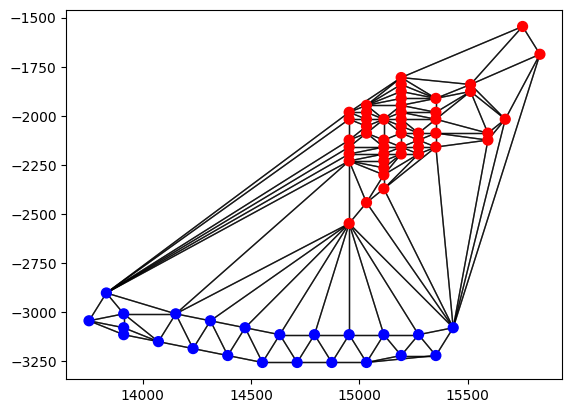

In [179]:
#lets plot our graph for fun!
edges_z = zs[torch_dataset[cluster_n].edge_index]
edges_x = xs[torch_dataset[cluster_n].edge_index]
plt.plot(edges_z.numpy(), edges_x.numpy(), 'k-', lw=1, alpha=0.7)
plt.scatter(zs, xs, c=colors, s=50, zorder=3)

In [198]:
def AddInfo(dbscan_hits, edep_events):
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    dbscan_cluster_list = []
    spills_in_file = np.unique(dbscan_hits[:,-4])
    iter_ = 0
    for spill_number in range(3): #spills_in_file:
        spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
        segments_in_spill = np.unique(spill_level[:,-2])
        for segment_number in segments_in_spill:
            time_segment_level = spill_level[spill_level[:,-2] == segment_number]
            clusters_in_segment = np.unique(time_segment_level[:,-1])
            for cluster_number in clusters_in_segment:
                dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
                rows = []
                #alright, for each hit can pull the m-nn, m-hn. 
                expected_hits = len(dbscan_cluster_level)
                for i, hit in enumerate(dbscan_cluster_level):
                    #assign refs 
                    m_nn = hit[0]
                    m_hn = hit[1]
                    ref_nn = m_nn
                    ref_hn = m_hn
                
                    #grab the const hit array
                    const_hit_array_nn = const_hit_array[const_hit_array[:,0] == m_nn]
                    const_hit_info = const_hit_array_nn[const_hit_array_nn[:,1] == m_hn]
                
                    #pull the default information. 
                    edep_events.GetEntry(int(m_nn)) #assign the event. Gets called at least once per hit. 
                    default_hit_segment = (event.SegmentDetectors['volTMS'])[int(m_hn)] #only pull one segment not all.
                    default_trackid = (default_hit_segment.Contrib)[0]
                    default_pdgid = ((event.Trajectories)[default_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in. 

                    #ok now we have the defaults. Two paths:

                    #If our pdgid is != 13, AND we have constituent hits to scan over, then lets scan over them.
                    if (abs(default_pdgid) != 13) and (np.shape(const_hit_info)[0] > 1):
                        #loop over the constituent hit nns, want to limit get entry calls
                        Replaced = False #monitors state, helps us break early or make sure to add our row at the end of no replacement is found. 
                        for constituent_hit_nn in np.unique(const_hit_info[:,2]):
                            #we have to loop over neutrino number since we have instances of merged hits w/ multiple neutrino events. 
                            #check state, and if it has already been replaced, continue no further. 
                            if Replaced == True:
                                break
                            edep_events.GetEntry(int(constituent_hit_nn)) #set the event. 
                            const_nn_sub_array = const_hit_info[const_hit_info[:,2] == constituent_hit_nn ] #grab the constituent hits w/ the desired neutrino number
                            for const_hit in const_nn_sub_array:
                                #another check of state!
                                if Replaced == True:
                                    break
                                
                                const_hit_number = const_hit[-1]
                                const_hit_segment = (event.SegmentDetectors['volTMS'])[int(const_hit_number)] #only pull one segment not all.
                                const_trackid = (const_hit_segment.Contrib)[0]
                                const_pdgid = ((event.Trajectories)[const_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in.
                            
                                #ok, so we've found an instance of a constituent w/ a pdgid of 13! Let's save our row. 
                                if (abs(const_pdgid) == 13):
                                    Replaced = True #set the state. 
                                    new_row = np.array((constituent_hit_nn, const_hit_number, hit[4], hit[2], hit[6], const_trackid, const_pdgid))
                                    rows.append(new_row)
                                    iter_ +=1 

                        #say we have loop over all constituents and found no muons, despite there being constituents, means our Replaced will still be False
                        if (Replaced == False):
                            #if found no replacement despite not being a muon by default, and having constituents, just append the defaults. 
                            new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                            rows.append(new_row)
                            iter_ +=1 
    
                    #Else -> Ie, our pdgid == 13, OR our pdgid != 13 but there is only 1 constituent hit, nothing to scan over, just save what we have as default. 
                    else:
                        new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                        rows.append(new_row)
                        iter_ +=1

                    if (iter_ % 100 == 0):
                        print(f'Added info through - {iter_}')

                #add to our running list, now grouped by cluster. 
                infod_hits = len(rows)
                if infod_hits != expected_hits:
                    print(f"Iter - {iter}, Expected {expected_hits}, got {infod_hits} - something is wrong!")
                dbscan_hits_with_info = np.vstack(rows)
                dbscan_cluster_list.append(dbscan_hits_with_info)
                    
    return(dbscan_cluster_list)

In [199]:
#our labeling logic. 
def AssignLabels(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
    
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
          
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
       
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
    
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

def RemoveDuplicates(labeled_slices_):
    filtered_slices = []
    for slice_labeled in labeled_slices_: #loop over slices
        xz = slice_labeled[:, [0, 1]] #pull the x and z subarray
        _, unique_indices, inverse = np.unique(xz, axis=0, return_index=True, return_inverse=True) #get the unique x and z instances (bars). Unique index is first appearance of a unique value, inverse is a mapping back

        selected_indices = []

        for group_id in range(len(unique_indices)):
            group_indices = np.where(inverse == group_id)[0] #grabbing indices of the actual locations in the slices labeled array using inverse
            group = slice_labeled[group_indices] #masking to pull subarray (need it to access labels)
    
            label_0_indices = group_indices[slice_labeled[group_indices, 3] == 0] #grab label 0 indices
            if len(label_0_indices) > 0: #if more than 1, pick first. This is the step at which the duplicate is eliminated, since will only pull the first instance w/ label 0 if several in the group index. 
                selected_indices.append(label_0_indices[0]) 
            else:
                selected_indices.append(group_indices[0]) #if no zero indices just grab first instance of the group. 

        filtered_labeled_slice = slice_labeled[selected_indices]  #selecting the subarray of our selected indices, there will be one per bar, w/ priority set on track. 
        filtered_slices.append(filtered_labeled_slice)
    
    return(filtered_slices)



In [200]:
dbscan_cluster_list = AddInfo(dbscan_hits, edep_events)
labels_added_duplicated_removed = RemoveDuplicates (AssignLabels(dbscan_cluster_list, edep_events))

Added info through - 100
Added info through - 200
Added info through - 300
Added info through - 400
Added info through - 500
Added info through - 600
Added info through - 700
Added info through - 800
Added info through - 900
Added info through - 1000
Added info through - 1100
Added info through - 1200
Added info through - 1300
Added info through - 1400
Added info through - 1500
Added info through - 1600
Added info through - 1700
Added info through - 1800
Added info through - 1900
Added info through - 2000
Added info through - 2100
Added info through - 2200
Added info through - 2300
Added info through - 2400
Added info through - 2500
Added info through - 2600
Added info through - 2700
Added info through - 2800
Added info through - 2900
Added info through - 3000
Added info through - 3100
Added info through - 3200
Added info through - 3300
Added info through - 3400
Added info through - 3500
Added info through - 3600
Added info through - 3700
Added info through - 3800
Added info through - 

In [207]:
def CreateGraphList(graph_points_list_): #takes an argument of a list of arrays containing the nodes for each cluster properly formatted
    graph_list = [] #list of torch graph objects
    for i, graph_points in enumerate(graph_points_list_):
        dbscan_cluster_object = graph_points #initialize our dbscan cluster.
        #create our graph nodes and features
        node_positions = np.asarray(dbscan_cluster_object[:, 0:2], dtype=float)
        node_features = dbscan_cluster_object[:,0:3]
        #node feature vector (z,x,PE)
        feature_vector = torch.tensor((node_features), dtype = torch.float)
        node_semantic_labels = torch.tensor((dbscan_cluster_object[:,3]), dtype = torch.long)

        #check min 3 points, max 1000 (this is kinda just an estimate for high end)
        if np.shape(dbscan_cluster_object)[0] < 3 or np.shape(dbscan_cluster_object)[0] > 1000:
            continue

        #check for enough distinct points to form a triangle
        unique_xs = np.unique(dbscan_cluster_object[:,1])
        unique_zs = np.unique(dbscan_cluster_object[:,0])
        if len(unique_xs) < 2 or len(unique_zs) < 2:
            continue

        
        #try-except block as a final filter for failed graphs 
        try:
            tri = Delaunay(node_positions)
        except Exception as e:
            print(f"Skipping cluster {i} due to Delaunay error: {e}")
            continue
        edges = set()
        
        for simplex in tri.simplices:
            for i in range(3):
                #indexes like (u,v) where u and v are the indexes of the points making up the edge
                u = simplex[i]
                v = simplex[(i + 1) % 3] #smart little trick, thanks internet!
                edges.add((u,v)) 
                edges.add((v,u)) #we want to add both directions, since undirected.       

        edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous() #need to transpose since torch expects EdgeIndex like [2, # edges], we produced [# edges, 2] contiguous is a memory flag for gpu opt. 
        #now we can package into a Data object for PyG
        graph_data = Data( x = feature_vector, edge_index = edge_index, y = node_semantic_labels)

        graph_list.append(graph_data)

    return(graph_list)

In [208]:
graphs = CreateGraphList(labels_added_duplicated_removed)

In [204]:
n_nodes = []
for graph in graphs:
    n_nodes.append(len(graph.y))

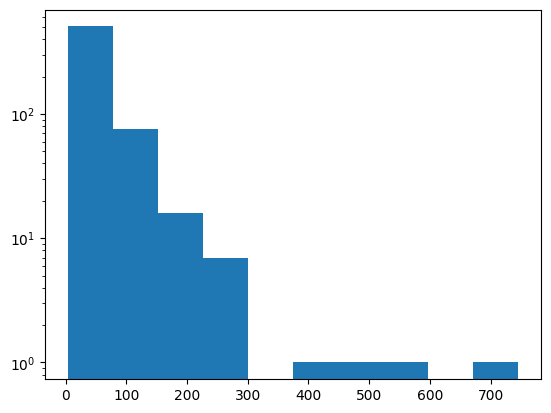

In [206]:
plt.hist(n_nodes)
plt.yscale('log')